<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Requirements:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
"> 
Compatible with data_handling.py and fit_FMR_class.py (currently only Generalizing-complex-fits branch)
<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
V Original
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
"> 

In [2]:
#Fine tuned version

In [1]:
import h5py
import numpy as np 
import sys

import matplotlib.pyplot as plt

from pathlib import Path

sys.path.append(r"C:\Users\jose1\OneDrive\PostDoc_FZU\DATA_analysis\VNA_data\VNA_analysis")
from data_handling import Analysis_FMR, FitStore
import fit_FMR_class as models
import complex_fits as fits
import fitting_functions as funcs
import resonance_functions as res_func
import calculators as calcs

import ipywidgets as widgets
from ipywidgets import interact

from scipy.optimize import curve_fit

<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Files Information:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
">
Fill in the information about the files to be analyzed. Create a class entity for each file with Analysis_PSWS()

In [3]:
#Folders where file are. Keep the r to use raw string in Windows.
address1 = Path(r"C:\Users\jose1\OneDrive\PostDoc_FZU\DATA\joseS\G228N2\inP_100\FMR_2026-06-04")

In [4]:
file_name_1 = "2026-06-04_FMR_fsw_0Ato19p5Ain81_0p5to49GHz_0dBm_18-48_analisys.h5.ma8"

In [8]:
sample = "F264N4_inP_1m10GaAs"

In [10]:
geometry = "inP" #either "inP" or "outP"

In [12]:
vna_ref_subtracted = True #Was a reference already subtracted during measurements?

In [14]:
ansy1 = Analysis_FMR(address1, file_name_1, sample, "FZU_FMR", geometry, vna_ref_subtracted)

In [16]:
store_in_origin = True #True if you wnat to store fit results in orignal file, otherwise another h5f file is created in the same directory

In [18]:
if store_in_origin:
    newFile = ansy1.file
else:
    newfile_name =  s.replace(".h5.ma8", "_LorentzFits.h5")
    newFile = address1/newfile_name

fits_storage = FitStore (newFile, group="Lorentzian fitting")

<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Data visualization:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
">
plot_dL_slider() allows one to preview the data for each field to select the best reference subraction.

In [21]:
ansy1.plot_dij_slider('d_S', n_0=5)

interactive(children=(IntSlider(value=5, description='Field index', max=80, readout_format='.0f'), Output()), …

In [15]:
#Ref. subtraction

In [16]:
ansy1.subtract_ref(single=False, fit=True, nb_g=1, ref_indx= 8) 
# ############It is saving a fuuuuull matrix of reference, no good

In [17]:
#Recheck data after new ref

In [18]:
# ansy1.plot_dij_slider('d_S', n_0=5)

In [19]:
# Example of a single fit

{'Ar': 1.872744020978698e-05, 'Ai': -3.794572010299726e-05, 'fo': 33.7, 'df': 0.02, 're0': 0.0, 'im0': 0.0}
Initial simplex fit


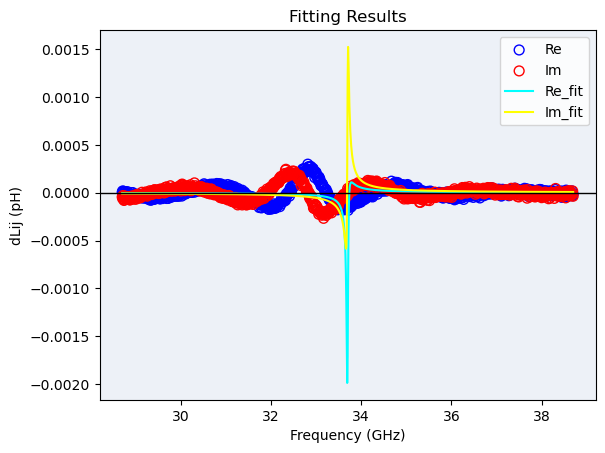

Final fit and results


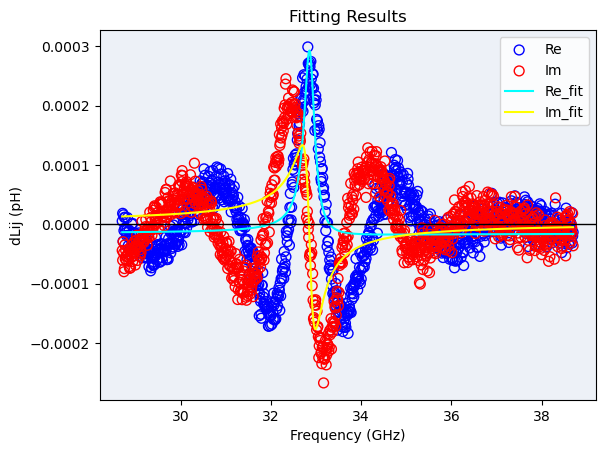


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -6.990e-06      1.969e-06         U        No
Ai                     4.406e-05      1.969e-06         U        No
fo                       32.8674         0.0087       GHz        No
df                        0.1437         0.0087       GHz        No
re0                   -1.538e-05      2.020e-06         U        No
im0                    2.681e-06      2.020e-06         U        No
----------------------------------------------------------------------
The phase is: 99.016254401292


In [20]:
ini_vals = [1, 1, 35, 0.028, 0, 0] #A, w, fres, fper, fref, re0, im0
H_index = 41
f_center = 33.7

f_min, f_max = f_center-5, f_center+5 #GHz
f_array = ansy1.freqs

y_array_re, y_array_im = ansy1.d_S("21R")[H_index], ansy1.d_S("21I")[H_index]
#y_array_re, y_array_im = dS21_Re_dH[H_index], dS21_Im_dH[H_index]

model = models.ComplexLorentzian_freq()
fitter = fits.ComplexFitter( ini_vals, f_min, f_max,
    f_array, y_array_re , y_array_im, model)
fitter.fix(fo=f_center, df=0.02, re0=0, im0=0) # Parameters to be fixed, empty otherwise
opt_p0 = fitter.simplex_wpm(method='Nelder-Mead')#'Powell'
print(opt_p0)
print("Initial simplex fit")
fitter.plot_fit_simplex_wpm()

new_p0 = np.array(list(opt_p0.values()), dtype=float)
fitter.update_p0(new_p0)

params, cov = fitter.fit(simplex_b=False)
print("Final fit and results")
fitter.plot_fit()
fitter.summary()
print(f"The phase is: {model.phase_deg(**params)}")

In [21]:
#If we are happy with the fit, we can save it.

In [22]:
fit_dict = fitter.export_fit_dict()

fits_storage.save(index=H_index,field=float(ansy1.calc_field("inP")[H_index]),fit_dict=fit_dict)

In [23]:
# Automatic fitting of entire spectra. Enter the estimated parameters for the Kittel model guiding the automatic fitting.

In [80]:
# est_gamma = 28.8 #GHz/T
# est_hx = 2150.0/1000 #T
# est_hy = -15/1000 #T

# for i in range(len(ansy1.calc_field("inP"))):
#     H_index = i
#     freq = res_func.kittel_general(ansy1.calc_field("inP")[H_index],est_gamma, est_hx, est_hy)
#     print(f"Index= {i}, Guide freq.={freq}")
#     ini_vals = [1, 1, freq, 0.028, 0, 0] #A, w, fres, fper, fref, re0, im0

    
#     f_min, f_max = freq-3, freq+3 #GHz
#     f_array = ansy1.freqs
#     y_array_re, y_array_im = ansy1.d_S("21R")[H_index], ansy1.d_S("21I")[H_index]
    
#     model = models.ComplexLorentzian_freq()
#     fitter = fits.ComplexFitter( ini_vals, f_min, f_max,
#         f_array, y_array_re , y_array_im, model)
#     fitter.fix(fo=freq, df=0.02, re0=0, im0=0) # Parameters to be fixed, empty otherwise
#     opt_p0 = fitter.simplex_wpm(method='Nelder-Mead')#'Powell'
#     #print(opt_p0)
#     #fitter.plot_fit_simplex_wpm()
#     new_p0 = np.array(list(opt_p0.values()), dtype=float)
#     fitter.update_p0(new_p0)
    
#     params, cov = fitter.fit(simplex_b=False)
#     fitter.plot_fit()
#     fitter.summary()
#     fit_dict = fitter.export_fit_dict()
#     fits_storage.save(index=H_index,field=float(ansy1.calc_field("inP")[H_index]),fit_dict=fit_dict)

In [25]:
#Realoading parameters

In [26]:
data_L_fits = fits_storage.load_fit_results(newFile, group="Lorentzian fitting")

In [27]:
fits_storage.plot_fit_parameters_subplots(
    data_L_fits,
    x_axis="index",
    params=["df", "fo"],
    x_label= "index"#"μ₀H (T)"
)

In [28]:
cut_data_L_fits = fits_storage.slice_dict(data_L_fits, 15, 72)

In [29]:
#Plotting of fitted parameters